# BART game-winner model (same dataset / split as `grid_search.ipynb`)

Bayesian Additive Regression Trees (via [`pymc-bart`](https://github.com/pymc-devs/pymc-bart))
trained on the **identical inputs** as the run-5 XGBoost model:

- same parquet (`schedule_and_weekly.parquet`) and identical seed-32 shuffle,
- same 54 RFE-selected features (`rfe_features_kfolds.csv`),
- same split — train `< 2022`, 2022–2023 slice, hold-out `>= 2024`.

One deliberate difference: XGBoost used the 2022–2023 slice for early stopping; BART has no
early-stopping mechanism, so that slice is reported as a pure validation check instead.
The latent BART function is pushed through a probit link to give `P(target team wins)`,
and predictions are posterior means — which also gives per-game uncertainty for free.

> **Sampler diagnostics note:** PGBART reports high r-hat / low ESS on some latent
> `mu` dimensions. This is common for BART latents and the posterior-mean *predictions*
> are stable across reruns (hold-out AUROC 0.702 with 2 chains vs 0.705 with 4 chains).

In [1]:
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import pymc as pm
import pymc_bart as pmb
import arviz as az

RANDOM_SEED = 32
# Same selected feature set as the run-5 XGBoost model; see rfe.ipynb
BEST_NUM_FEATS = 54
TARGET = 'target_win'

BEST_FEATS_FROM_RFE = list(pd.read_csv(
    '../../../../../data/predict_games/model_features_in/rfe_features_kfolds.csv',
    index_col=0
).loc[BEST_NUM_FEATS, :].dropna().values)

MODEL_INPUTS_DF = pd.read_parquet(
    '../../../../../data/predict_games/input_data/schedule_and_weekly.parquet'
)

MODEL_INPUTS_DF = MODEL_INPUTS_DF.sample(
    frac=1, random_state=RANDOM_SEED
).reset_index(drop=True)

np.random.seed(RANDOM_SEED)

In [2]:
# Identical split to grid_search.ipynb: train on everything before 2022, keep the
# 2022-2023 slice (XGBoost's early-stopping set) as a validation check, and hold out
# 2024+2025 for the headline out-of-sample metrics.
train_df = MODEL_INPUTS_DF[(MODEL_INPUTS_DF['season'] < 2022)]
valid_df = MODEL_INPUTS_DF[
    (MODEL_INPUTS_DF['season'] >= 2022) & (MODEL_INPUTS_DF['season'] < 2024)
]
holdout_df = MODEL_INPUTS_DF[MODEL_INPUTS_DF['season'] >= 2024].copy()

X_train = train_df[BEST_FEATS_FROM_RFE].to_numpy(dtype=float)
y_train = train_df[TARGET].to_numpy(dtype=int)
X_valid = valid_df[BEST_FEATS_FROM_RFE].to_numpy(dtype=float)
y_valid = valid_df[TARGET].to_numpy(dtype=int)
X_holdout = holdout_df[BEST_FEATS_FROM_RFE].to_numpy(dtype=float)
y_holdout = holdout_df[TARGET].to_numpy(dtype=int)

print(f'train {X_train.shape}, valid {X_valid.shape}, holdout {X_holdout.shape}')

train (9724, 54), valid (1086, 54), holdout (1088, 54)


In [3]:
# Probit-link BART: a sum of m=50 trees models the latent score, invprobit maps it to
# P(target team wins). shape=mu.shape lets pm.set_data swap in new X for prediction.
with pm.Model() as bart_model:
    X_data = pm.Data('X', X_train)
    mu = pmb.BART('mu', X_data, y_train, m=50)
    p = pm.Deterministic('p', pm.math.invprobit(mu))
    pm.Bernoulli('y', p=p, observed=y_train, shape=mu.shape)
    idata = pm.sample(
        draws=1000, tune=1000, chains=4, cores=4,
        random_seed=RANDOM_SEED, progressbar=False,
    )

Multiprocess sampling (4 chains in 4 jobs)


PGBART: [mu]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 74 seconds.


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [4]:
def bart_predict(X_new):
    """Posterior-mean P(win) and per-row posterior std at new inputs."""
    with bart_model:
        pm.set_data({'X': X_new})
        ppc = pm.sample_posterior_predictive(
            idata, var_names=['p'], random_seed=RANDOM_SEED, progressbar=False
        )
    post_p = ppc.posterior_predictive['p']
    return (
        post_p.mean(dim=['chain', 'draw']).to_numpy(),
        post_p.std(dim=['chain', 'draw']).to_numpy(),
    )

valid_preds, _ = bart_predict(X_valid)
holdout_preds, holdout_pred_std = bart_predict(X_holdout)

Sampling: [mu]


Sampling: [mu]


In [5]:
# Headline out-of-sample metrics, directly comparable to run 5 of the XGBoost model
# (pooled hold-out ROC-AUC 0.697, accuracy 0.647).
valid_auc = roc_auc_score(y_valid, valid_preds)
holdout_auc = roc_auc_score(y_holdout, holdout_preds)
holdout_acc = ((holdout_preds > 0.5).astype(int) == y_holdout).mean()
print(f'2022-2023 validation ROC-AUC: {valid_auc:.4f}')
print(f'2024+2025 hold-out  ROC-AUC: {holdout_auc:.4f}')
print(f'2024+2025 hold-out accuracy: {holdout_acc:.4f}')

2022-2023 validation ROC-AUC: 0.6548
2024+2025 hold-out  ROC-AUC: 0.7049
2024+2025 hold-out accuracy: 0.6599


In [6]:
holdout_df.loc[:, 'preds'] = holdout_preds
holdout_df.loc[:, 'preds_std'] = holdout_pred_std

results_df = holdout_df[
    ['game_id', 'week', 'target_team', 'opp_team', 'target_win', 'preds', 'preds_std']
].copy()
results_df.sort_values(by='game_id', inplace=True)
results_df.reset_index(drop=True, inplace=True)
results_df

,game_id,week,target_team,opp_team,target_win,preds,preds_std
0,2024_01_ARI_BUF,1,ARI,BUF,0,0.206684,0.050316
1,2024_01_ARI_BUF,1,BUF,ARI,1,0.782811,0.052168
2,2024_01_BAL_KC,1,KC,BAL,1,0.557015,0.072740
3,2024_01_BAL_KC,1,BAL,KC,0,0.416617,0.067211
4,2024_01_CAR_NO,1,CAR,NO,0,0.208762,0.045063
...,...,...,...,...,...,...,...
1083,2025_18_SEA_SF,18,SF,SEA,0,0.506041,0.065605
1084,2025_18_TEN_JAX,18,JAX,TEN,1,0.773569,0.048346
1085,2025_18_TEN_JAX,18,TEN,JAX,0,0.209197,0.047415
1086,2025_18_WAS_PHI,18,PHI,WAS,0,0.723544,0.056625


per-week mean AUROC: 0.7073


week
1     0.922852
2     0.708984
3     0.526367
4     0.564453
5     0.478316
6     0.746730
7     0.796667
8     0.759810
9     0.725327
10    0.706633
11    0.821641
12    0.784636
13    0.739258
14    0.737997
15    0.757812
16    0.618164
17    0.683594
18    0.652344
dtype: float64

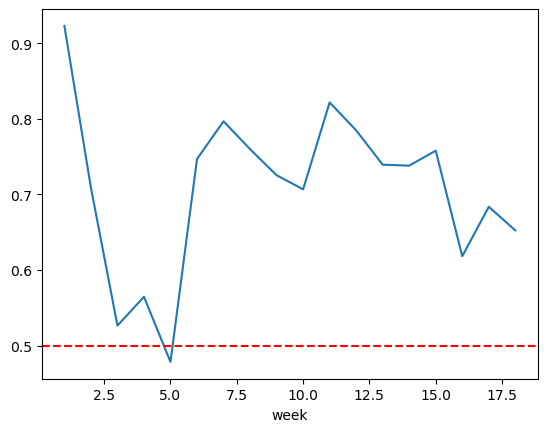

In [7]:
# AUROC by hold-out week (same view as grid_search.ipynb)
weekly_scores = holdout_df.groupby('week').apply(
    lambda x: roc_auc_score(x['target_win'], x['preds']),
    include_groups=False
)
weekly_scores.plot()
plt.axhline(y=.5, color='r', linestyle='--')
print(f'per-week mean AUROC: {weekly_scores.mean():.4f}')
weekly_scores

In [8]:
# Residual-based metrics. Unlike AUROC, these penalize confident-and-wrong predictions.
from sklearn.metrics import brier_score_loss, log_loss

brier = brier_score_loss(holdout_df['target_win'], holdout_df['preds'])
ll = log_loss(holdout_df['target_win'], holdout_df['preds'])
print(f"Brier score: {brier:.4f}  (lower is better; 0.25 = coin flip)")
print(f"Log loss:    {ll:.4f}  (lower is better; punishes confident-and-wrong hardest)")

Brier score: 0.2194  (lower is better; 0.25 = coin flip)
Log loss:    0.6288  (lower is better; punishes confident-and-wrong hardest)


In [9]:
# Confidence-bucketed accuracy: keep the higher-probability row per game, bucket by
# the model's confidence in its pick, and check accuracy inside each bucket.
higher_preds = holdout_df.groupby('game_id').apply(
    lambda x: x.loc[x['preds'].idxmax(), :],
    include_groups=False
)
higher_preds.reset_index(drop=True, inplace=True)
higher_preds['confidence'] = higher_preds['preds']
higher_preds['bucket'] = pd.cut(
    higher_preds['confidence'], bins=[0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
)

confidence_summary = higher_preds.groupby('bucket', observed=True).agg(
    n_games=('target_win', 'size'),
    pick_accuracy=('target_win', 'mean'),
    avg_confidence=('confidence', 'mean'),
)
confidence_summary['calibration_gap'] = (
    confidence_summary['avg_confidence'] - confidence_summary['pick_accuracy']
)
confidence_summary

,n_games,pick_accuracy,avg_confidence,calibration_gap
bucket,,,,
"(0.5, 0.6]",245,0.620408,0.550301,-0.070107
"(0.6, 0.7]",190,0.647368,0.643839,-0.003529
"(0.7, 0.8]",82,0.817073,0.744215,-0.072858
"(0.8, 0.9]",6,1.000000,0.826814,-0.173186


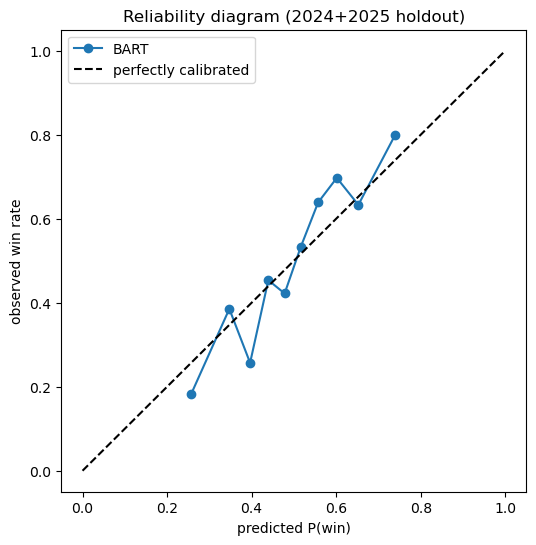

In [10]:
# Reliability diagram: are the probabilities trustworthy?
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(
    holdout_df['target_win'], holdout_df['preds'], n_bins=10, strategy='quantile'
)
plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, marker='o', label='BART')
plt.plot([0, 1], [0, 1], 'k--', label='perfectly calibrated')
plt.xlabel('predicted P(win)')
plt.ylabel('observed win rate')
plt.title('Reliability diagram (2024+2025 holdout)')
plt.legend()
plt.show()

In [11]:
# Home-vs-away probability gap: does a wider gap predict better? (run-5 comparison: r=0.21)
game_view = holdout_df.pivot_table(
    index='game_id', columns='is_home_target', values=['preds', 'target_win'], aggfunc='first'
).dropna()

games = pd.DataFrame({
    'home_pred': game_view[('preds', 1)],
    'away_pred': game_view[('preds', 0)],
    'home_won':  game_view[('target_win', 1)].astype(int),
})
games['gap']           = games['home_pred'] - games['away_pred']
games['abs_gap']       = games['gap'].abs()
games['pred_home_win'] = games['home_pred'] > games['away_pred']
games['correct']       = games['pred_home_win'] == (games['home_won'] == 1)

games['gap_quintile'] = pd.qcut(games['abs_gap'], 5)
gap_summary = games.groupby('gap_quintile', observed=True).agg(
    n_games=('correct', 'size'),
    mean_abs_gap=('abs_gap', 'mean'),
    accuracy=('correct', 'mean'),
)
print(f"Overall correlation(abs_gap, correct): {games['abs_gap'].corr(games['correct'].astype(int)):.3f}")
gap_summary

Overall correlation(abs_gap, correct): 0.174


,n_games,mean_abs_gap,accuracy
gap_quintile,,,
"(-7.6e-05, 0.0794]",109,0.036833,0.559633
"(0.0794, 0.161]",109,0.118713,0.623853
"(0.161, 0.25]",108,0.204367,0.685185
"(0.25, 0.365]",109,0.305033,0.633028
"(0.365, 0.729]",109,0.479689,0.807339


## What BART adds: posterior uncertainty

Unlike XGBoost's point probabilities, each prediction here is a full posterior. If the
uncertainty is meaningful, picks the model is *sure* about (narrow posterior) should be
right more often than picks with a wide posterior.

In [12]:
# Accuracy by posterior-uncertainty quartile (per game, on the model's pick)
higher_preds['pick_correct'] = higher_preds['target_win'] == 1
higher_preds['std_quartile'] = pd.qcut(higher_preds['preds_std'], 4, labels=['narrowest', 'q2', 'q3', 'widest'])

uncertainty_summary = higher_preds.groupby('std_quartile', observed=True).agg(
    n_games=('pick_correct', 'size'),
    pick_accuracy=('pick_correct', 'mean'),
    avg_posterior_std=('preds_std', 'mean'),
    avg_confidence=('confidence', 'mean'),
)
uncertainty_summary

,n_games,pick_accuracy,avg_posterior_std,avg_confidence
std_quartile,,,,
narrowest,136,0.786765,0.052816,0.699988
q2,136,0.625000,0.059383,0.603369
q3,136,0.647059,0.062819,0.583300
widest,136,0.588235,0.067817,0.565171


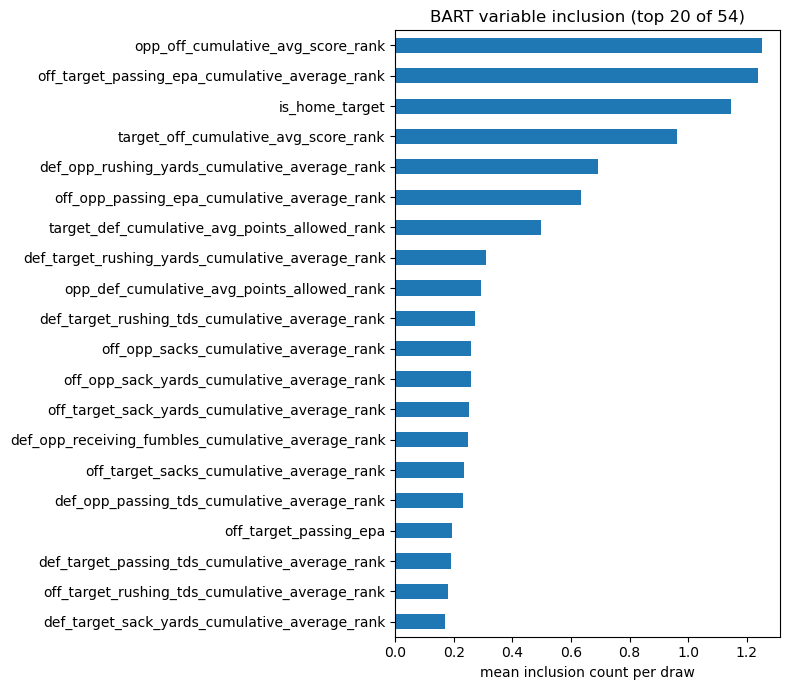

In [13]:
# Variable importance: how often each feature is used in the trees' splitting rules,
# averaged over posterior draws.
vi = idata.sample_stats['variable_inclusion'].mean(dim=['chain', 'draw']).to_numpy()
vi_series = pd.Series(vi, index=BEST_FEATS_FROM_RFE).sort_values(ascending=True)
vi_series.tail(20).plot.barh(figsize=(8, 7))
plt.xlabel('mean inclusion count per draw')
plt.title('BART variable inclusion (top 20 of 54)')
plt.tight_layout()
plt.show()